# Exploratory Data Analysis (EDA)
## Marketing Campaign Analysis — iFood Customer Dataset

**Nama Siswa:** Siti Fatimah Nur Az-Zahra
**Tanggal:** Rabu, 09 September 2026
**Dataset:** 03_Clean_Dataset.csv (2.021 baris, hasil cleaning OpenRefine)

**Business Question yang dijawab (dari Project Charter):**
1. Berapa tingkat penerimaan (acceptance rate) masing-masing kampanye historis?
2. Segmen pelanggan mana yang paling responsif terhadap kampanye?
3. Apakah pola belanja/kunjungan web berkorelasi dengan kemungkinan menerima kampanye?
4. Kampanye mana yang paling efektif dibandingkan kampanye lainnya?
5. Strategi targeting seperti apa yang direkomendasikan untuk kampanye berikutnya?


## 0. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
COLOR = '#4472C4'
COLOR2 = '#ED7D31'

df = pd.read_csv('03_Clean_Dataset.csv')
print("Jumlah baris:", df.shape[0], "| Jumlah kolom:", df.shape[1])
df.head()

Jumlah baris: 2021 | Jumlah kolom: 41


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Education,Marital_Status
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,1,0,0,1529,1441,0,Graduation,Single
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,1,0,0,21,15,0,Graduation,Single
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,1,0,0,734,692,0,Graduation,Together
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,1,0,0,48,43,0,Graduation,Together
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,1,407,392,0,PhD,Married


In [2]:
# Rekonstruksi kolom kategorikal dari one-hot encoding untuk kemudahan visualisasi
edu_cols = [c for c in df.columns if c.startswith('education_')]
marital_cols = [c for c in df.columns if c.startswith('marital_')]

def reconstruct(row, cols, prefix):
    for c in cols:
        if row[c] == 1:
            return c.replace(prefix, '')
    return 'Unknown'

df['Education'] = df.apply(lambda r: reconstruct(r, edu_cols, 'education_'), axis=1)
df['Marital_Status'] = df.apply(lambda r: reconstruct(r, marital_cols, 'marital_'), axis=1)
df[['Education','Marital_Status']].head()

,Education,Marital_Status
0,Graduation,Single
1,Graduation,Single
2,Graduation,Together
3,Graduation,Together
4,PhD,Married


## 1. Univariate Analysis
Melihat distribusi masing-masing variabel secara terpisah.

In [3]:
df[['Income','Age','Recency','MntTotal','NumWebVisitsMonth']].describe()

,Income,Age,Recency,MntTotal,NumWebVisitsMonth
count,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,51.117269,48.880752,563.789213,5.340426
std,20713.046401,11.667616,28.950917,576.775749,2.426319
min,1730.000000,24.000000,0.000000,4.000000,0.000000
25%,35416.000000,43.000000,24.000000,55.000000,3.000000
50%,51412.000000,50.000000,49.000000,343.000000,6.000000
75%,68274.000000,61.000000,74.000000,964.000000,7.000000
max,113734.000000,80.000000,99.000000,2491.000000,20.000000


**Statistik deskriptif** menunjukkan rata-rata Income pelanggan sekitar Rp 51-52 juta dengan variasi cukup lebar, dan rata-rata usia sekitar 45 tahun.

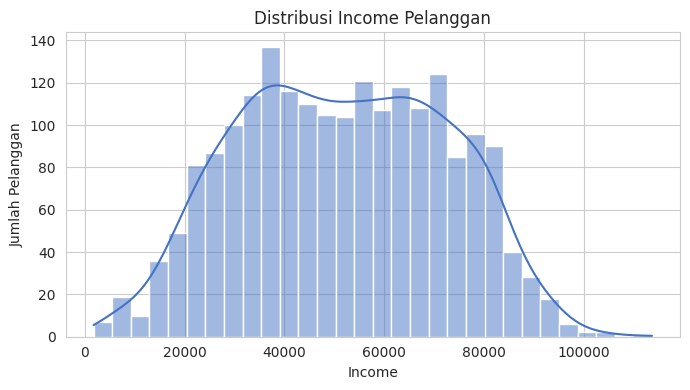

In [4]:
plt.figure(figsize=(7,4))
sns.histplot(df['Income'], bins=30, color=COLOR, kde=True)
plt.title('Distribusi Income Pelanggan')
plt.xlabel('Income'); plt.ylabel('Jumlah Pelanggan')
plt.tight_layout(); plt.show()

**Insight 1:** Distribusi Income condong ke kanan (right-skewed) — mayoritas pelanggan berada di rentang income menengah (Rp20-70 juta), dengan sedikit pelanggan berpenghasilan sangat tinggi (>Rp100 juta) yang menjadi outlier alami.

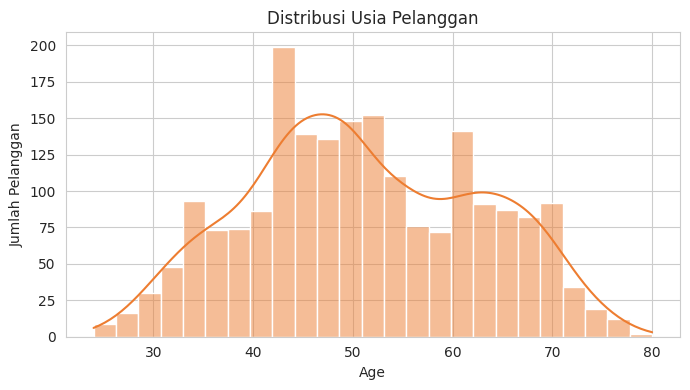

In [5]:
plt.figure(figsize=(7,4))
sns.histplot(df['Age'], bins=25, color=COLOR2, kde=True)
plt.title('Distribusi Usia Pelanggan')
plt.xlabel('Age'); plt.ylabel('Jumlah Pelanggan')
plt.tight_layout(); plt.show()

**Insight 2:** Mayoritas pelanggan berusia 35-65 tahun, dengan puncak di sekitar usia 45-50 tahun — menunjukkan basis pelanggan didominasi kelompok usia produktif-matang, bukan anak muda.

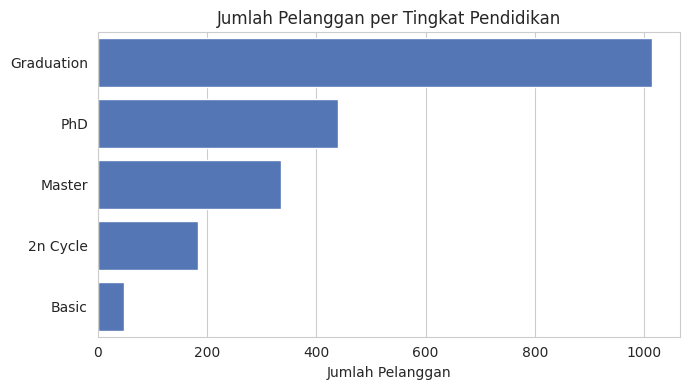

In [6]:
plt.figure(figsize=(7,4))
order = df['Education'].value_counts().index
sns.countplot(y='Education', data=df, order=order, color=COLOR)
plt.title('Jumlah Pelanggan per Tingkat Pendidikan')
plt.xlabel('Jumlah Pelanggan'); plt.ylabel('')
plt.tight_layout(); plt.show()

**Insight 3:** Mayoritas pelanggan (>60%) memiliki pendidikan Graduation (S1), diikuti PhD dan Master — basis pelanggan didominasi kelompok berpendidikan tinggi.

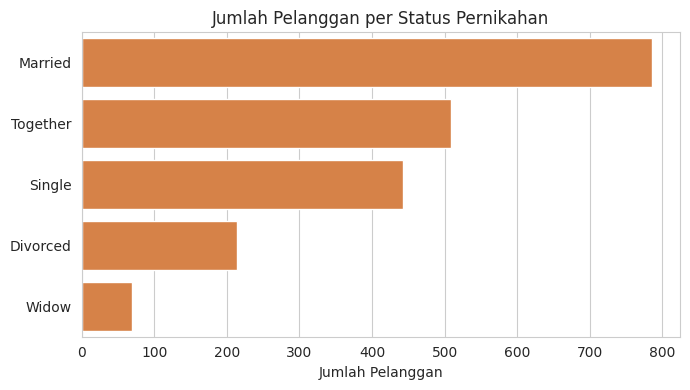

In [7]:
plt.figure(figsize=(7,4))
order2 = df['Marital_Status'].value_counts().index
sns.countplot(y='Marital_Status', data=df, order=order2, color=COLOR2)
plt.title('Jumlah Pelanggan per Status Pernikahan')
plt.xlabel('Jumlah Pelanggan'); plt.ylabel('')
plt.tight_layout(); plt.show()

**Insight 4:** Status 'Married' dan 'Together' mendominasi lebih dari 60% pelanggan, menunjukkan basis pelanggan mayoritas sudah berpasangan/berkeluarga.

## 2. Trend Analysis
Melihat perubahan tingkat penerimaan kampanye dari waktu ke waktu (Campaign 1 s.d. kampanye terbaru).

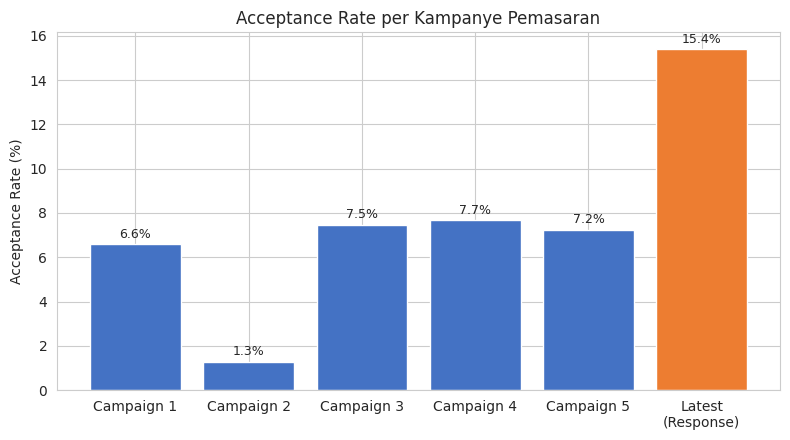

AcceptedCmp1: 6.58%
AcceptedCmp2: 1.29%
AcceptedCmp3: 7.47%
AcceptedCmp4: 7.67%
AcceptedCmp5: 7.22%
Response: 15.39%


In [8]:
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
cmp_labels = ['Campaign 1','Campaign 2','Campaign 3','Campaign 4','Campaign 5','Latest\n(Response)']
rates = [df[c].mean()*100 for c in cmp_cols]

plt.figure(figsize=(8,4.5))
bars = plt.bar(cmp_labels, rates, color=[COLOR]*5+[COLOR2])
for b, r in zip(bars, rates):
    plt.text(b.get_x()+b.get_width()/2, r+0.3, f'{r:.1f}%', ha='center', fontsize=9)
plt.title('Acceptance Rate per Kampanye Pemasaran')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout(); plt.show()

for c, r in zip(cmp_cols, rates):
    print(f"{c}: {r:.2f}%")

**Insight 5 (menjawab Business Question #1 & #4):** Kampanye ke-2 (Campaign 2) memiliki acceptance rate paling rendah (±1.3%), sementara kampanye terbaru (Response) memiliki acceptance rate tertinggi (±15.4%) — lebih dari 10x lipat dibanding Campaign 2. Ini mengindikasikan strategi kampanye terbaru jauh lebih efektif, kemungkinan karena penargetan atau penawaran yang lebih relevan.

## 3. Bivariate Analysis
Melihat hubungan antar variabel, khususnya terhadap `Response` (penerimaan kampanye terbaru).

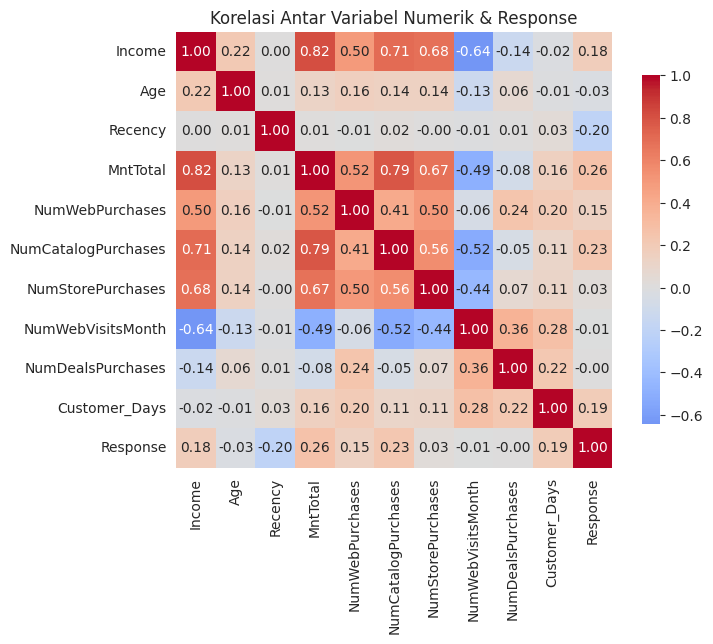

Response               1.000000
MntTotal               0.261421
NumCatalogPurchases    0.233975
Customer_Days          0.190446
Income                 0.175167
NumWebPurchases        0.145522
NumStorePurchases      0.030087
NumDealsPurchases     -0.000464
NumWebVisitsMonth     -0.005581
Age                   -0.026153
Recency               -0.203954
Name: Response, dtype: float64


In [9]:
num_cols = ['Income','Age','Recency','MntTotal','NumWebPurchases','NumCatalogPurchases',
            'NumStorePurchases','NumWebVisitsMonth','NumDealsPurchases','Customer_Days','Response']
plt.figure(figsize=(8,6.5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink':0.8})
plt.title('Korelasi Antar Variabel Numerik & Response')
plt.tight_layout(); plt.show()

print(corr['Response'].sort_values(ascending=False))

**Insight 6:** `MntTotal` (total pengeluaran) memiliki korelasi positif tertinggi dengan Response (0.26), diikuti `NumCatalogPurchases` (0.23) dan `Customer_Days` (0.19). Sebaliknya, `Recency` (hari sejak pembelian terakhir) berkorelasi negatif (-0.20) — semakin baru transaksi terakhir pelanggan, semakin besar kemungkinan mereka merespons kampanye.

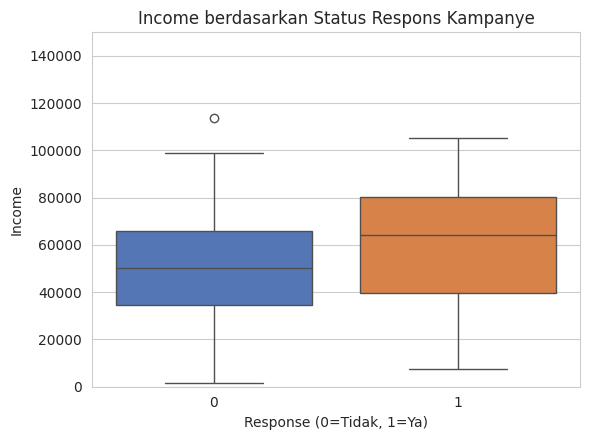

Response
0    50140.325146
1    60192.906752
Name: Income, dtype: float64


In [10]:
plt.figure(figsize=(6,4.5))
sns.boxplot(x='Response', y='Income', hue='Response', data=df, palette=[COLOR, COLOR2], legend=False)
plt.title('Income berdasarkan Status Respons Kampanye')
plt.xlabel('Response (0=Tidak, 1=Ya)'); plt.ylabel('Income')
plt.ylim(0, 150000)
plt.tight_layout(); plt.show()

print(df.groupby('Response')['Income'].mean())

**Insight 7 (menjawab Business Question #3):** Rata-rata Income pelanggan yang merespons kampanye (~Rp60,2 juta) lebih tinggi dibanding yang tidak merespons (~Rp50,1 juta) — mengindikasikan pelanggan berpenghasilan lebih tinggi cenderung lebih responsif terhadap kampanye.

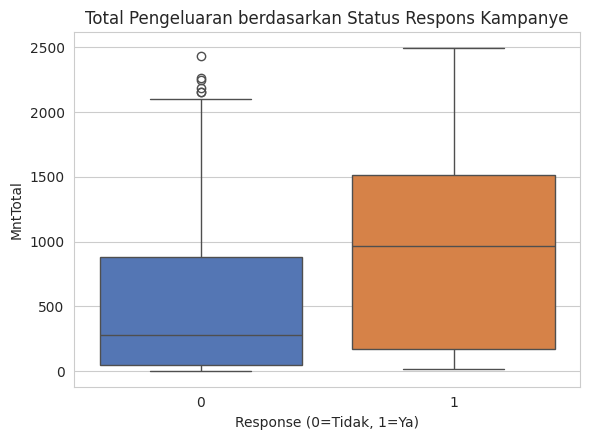

Response
0    499.502339
1    917.263666
Name: MntTotal, dtype: float64


In [11]:
plt.figure(figsize=(6,4.5))
sns.boxplot(x='Response', y='MntTotal', hue='Response', data=df, palette=[COLOR, COLOR2], legend=False)
plt.title('Total Pengeluaran berdasarkan Status Respons Kampanye')
plt.xlabel('Response (0=Tidak, 1=Ya)'); plt.ylabel('MntTotal')
plt.tight_layout(); plt.show()

print(df.groupby('Response')['MntTotal'].mean())

**Insight 8:** Pelanggan yang merespons kampanye rata-rata berbelanja hampir 2x lebih banyak (~917) dibanding yang tidak merespons (~500) — menunjukkan pelanggan dengan histori belanja tinggi adalah target yang lebih potensial untuk kampanye.

## 4. Segmentation Analysis
Melihat tingkat penerimaan kampanye (Response Rate) berdasarkan segmen pelanggan.

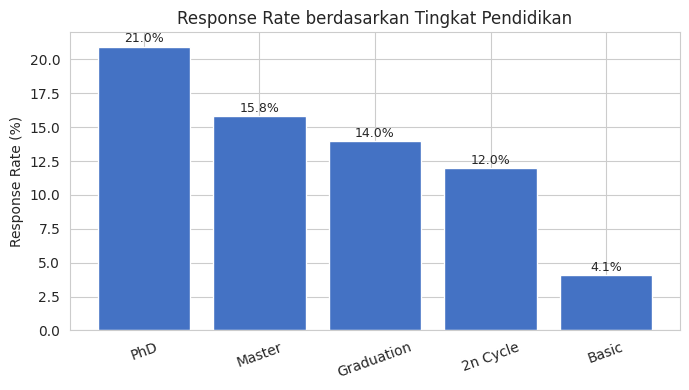

Education
PhD           20.956720
Master        15.820896
Graduation    13.990148
2n Cycle      12.021858
Basic          4.081633
Name: Response, dtype: float64


In [12]:
seg_edu = df.groupby('Education')['Response'].mean().sort_values(ascending=False)*100
plt.figure(figsize=(7,4))
bars = plt.bar(seg_edu.index, seg_edu.values, color=COLOR)
for b, r in zip(bars, seg_edu.values):
    plt.text(b.get_x()+b.get_width()/2, r+0.3, f'{r:.1f}%', ha='center', fontsize=9)
plt.title('Response Rate berdasarkan Tingkat Pendidikan')
plt.ylabel('Response Rate (%)'); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

print(seg_edu)

**Insight 9 (menjawab Business Question #2):** Pelanggan dengan pendidikan **PhD** memiliki response rate tertinggi (21.0%), sementara pendidikan **Basic** terendah jauh di bawah (4.1%) — gap sekitar 5x lipat. Tingkat pendidikan berkorelasi positif dengan kemungkinan merespons kampanye.

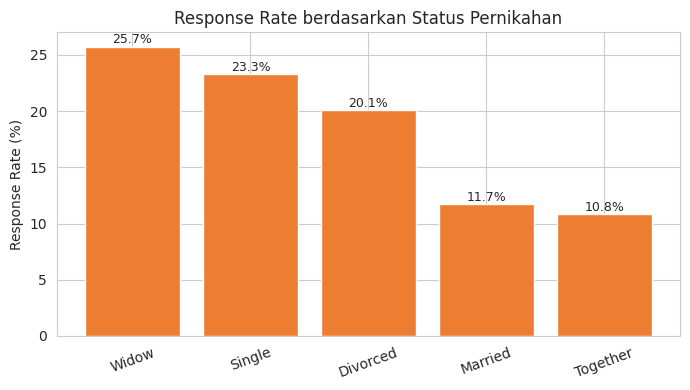

Marital_Status
Widow       25.714286
Single      23.250564
Divorced    20.093458
Married     11.719745
Together    10.805501
Name: Response, dtype: float64


In [13]:
seg_mar = df.groupby('Marital_Status')['Response'].mean().sort_values(ascending=False)*100
plt.figure(figsize=(7,4))
bars = plt.bar(seg_mar.index, seg_mar.values, color=COLOR2)
for b, r in zip(bars, seg_mar.values):
    plt.text(b.get_x()+b.get_width()/2, r+0.3, f'{r:.1f}%', ha='center', fontsize=9)
plt.title('Response Rate berdasarkan Status Pernikahan')
plt.ylabel('Response Rate (%)'); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

print(seg_mar)

**Insight 10:** Pelanggan berstatus **Widow** (25.7%) dan **Single** (23.3%) jauh lebih responsif dibanding **Married** (11.7%) dan **Together** (10.8%) — pelanggan yang hidup sendiri (tanpa pasangan) lebih mungkin merespons kampanye promosi.

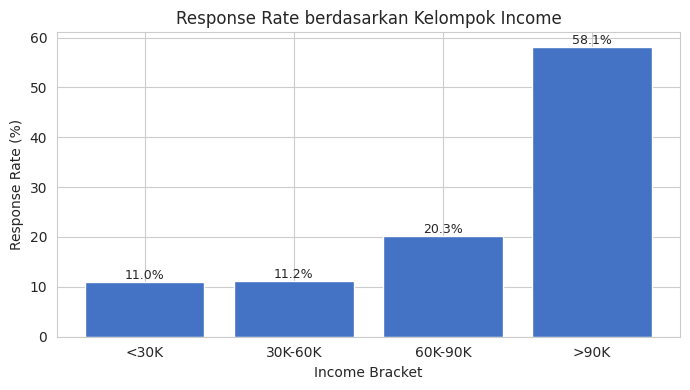

Income_Bracket
<30K       10.979228
30K-60K    11.243243
60K-90K    20.251397
>90K       58.139535
Name: Response, dtype: float64


In [14]:
df['Income_Bracket'] = pd.cut(df['Income'], bins=[0,30000,60000,90000,200000],
                                labels=['<30K','30K-60K','60K-90K','>90K'])
seg_inc = df.groupby('Income_Bracket', observed=True)['Response'].mean()*100
plt.figure(figsize=(7,4))
bars = plt.bar(seg_inc.index.astype(str), seg_inc.values, color=COLOR)
for b, r in zip(bars, seg_inc.values):
    plt.text(b.get_x()+b.get_width()/2, r+0.5, f'{r:.1f}%', ha='center', fontsize=9)
plt.title('Response Rate berdasarkan Kelompok Income')
plt.ylabel('Response Rate (%)'); plt.xlabel('Income Bracket')
plt.tight_layout(); plt.show()

print(seg_inc)

**Insight 11:** Response rate melonjak tajam pada kelompok income **>90K** (58.1%) dibanding kelompok income lain yang berkisar 11-20%. Kelompok income tinggi adalah segmen paling responsif secara signifikan.

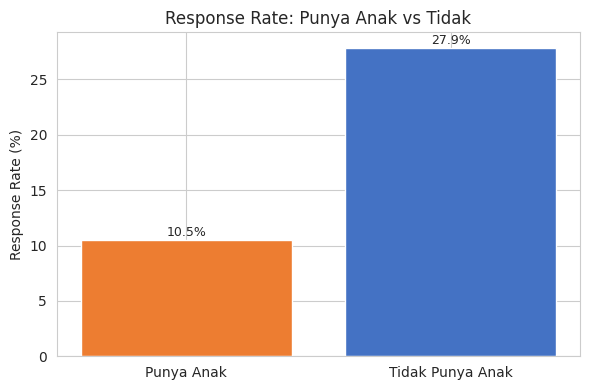

Has_Children
Punya Anak          10.522696
Tidak Punya Anak    27.865961
Name: Response, dtype: float64


In [15]:
df['Has_Children'] = ((df['Kidhome']>0) | (df['Teenhome']>0)).map({True:'Punya Anak', False:'Tidak Punya Anak'})
seg_child = df.groupby('Has_Children')['Response'].mean()*100
plt.figure(figsize=(6,4))
bars = plt.bar(seg_child.index, seg_child.values, color=[COLOR2, COLOR])
for b, r in zip(bars, seg_child.values):
    plt.text(b.get_x()+b.get_width()/2, r+0.3, f'{r:.1f}%', ha='center', fontsize=9)
plt.title('Response Rate: Punya Anak vs Tidak')
plt.ylabel('Response Rate (%)')
plt.tight_layout(); plt.show()

print(seg_child)

**Insight 12:** Pelanggan **tanpa anak** di rumah memiliki response rate hampir 3x lebih tinggi (27.9%) dibanding pelanggan yang punya anak (10.5%) — kemungkinan karena pelanggan tanpa anak punya lebih banyak diskresi belanja untuk diri sendiri.

## 5. Key Findings & Summary

### 3 Temuan Utama:

**1. Kampanye terbaru jauh lebih efektif dari kampanye historis**
Acceptance rate kampanye terbaru (Response = 15,4%) lebih dari 10x lipat dibanding Campaign 2 (1,3%), kampanye historis dengan performa terburuk. Ini menunjukkan ada perbaikan signifikan dalam strategi kampanye terbaru yang bisa dipelajari dan direplikasi.

**2. Segmen "premium & tanpa anak" adalah target paling potensial**
Kombinasi income tinggi (>90K), tidak memiliki anak di rumah, status Single/Widow, dan pendidikan tinggi (PhD/Master) menunjukkan response rate jauh di atas rata-rata (mencapai 58% untuk kelompok income >90K). Segmen ini sebaiknya menjadi prioritas utama pada kampanye mendatang.

**3. Histori belanja & keterkinian transaksi adalah prediktor kuat**
Pelanggan dengan total belanja tinggi (MntTotal) dan transaksi baru-baru ini (Recency rendah) jauh lebih mungkin merespons kampanye. Targeting berbasis RFM (Recency, Frequency, Monetary) berpotensi meningkatkan efektivitas kampanye secara signifikan.

### Rekomendasi Awal (untuk dielaborasi di Root Cause Analysis - Hari Kamis):
- Prioritaskan targeting ke pelanggan income tinggi, tanpa anak, dan pendidikan tinggi
- Pelajari strategi Campaign terbaru (Response) yang lebih efektif untuk direplikasi ke kampanye berikutnya
- Gunakan Recency & Total Spending sebagai filter utama sebelum mengirim kampanye untuk efisiensi biaya
